# Text Analytics Lab 3: Classifiers

This notebook uses classifiers from Scikit-learn and introduces a new library, Pytorch, to construct simple neural networks for processing text. 

NLP pipelines perform a series of steps to preprocess and then extract features from a piece of text to form a suitable representation to input to a classifier.
Naïve Bayes and logistic regression are examples of classifiers that depend on careful preprocessing and feature engineering. 
Neural networks allow us to reduce the amount of feature engineering by learning representations in the hidden layers from large amounts of data. 

Naïve Bayes is a generative model: we learn probability distributions that can be used to sample bags of words. Logistic regression and neural network classifier are disciminative: they learn the classification task directly, without learning to generate the text. However, neural networks also differ from logistic regression because they can model nonlinear functions of their inputs. This is achieved by having hidden layers with nonlinear activation functions. 

Some key advantages of a neural network classifier:
   * It can model nonlinear functions, so can handle much more complex relationships between features and class labels.
   * It performs representation learning: the hidden layers learn how to extract features from low-level data.
   * It can process sequences of tokens -- we don't have to think in terms of a single feature vector representing a document as we did for logistic regression.

On the other hand, the downsides are:
   * Much more expensive to train and test.
   * It can overfit very badly to small datasets.
   * The features learned by the hidden layers can be hard to interpret, which can make it hard to predict the model's behaviour, e.g., what sort of cases it may fail on.
   * Generalisation is unpredictable: they sometimes behave in unexpected ways when applied to test data outside the training set distribution. 

## Learning Outcomes

These sections will contain tutorial-like instructions, as you have seen in previous text analytics labs. On completing these sections, you should be able to...
1. Train and test naïve Bayes and logistic regression classifiers.
1. For naïve Bayes and logistic regression classifiers, examine their parameters and explain how they make decisions.
1. Recognise the steps required to train and test a neural text classifier with Pytorch.
1. Modify the architecture of a neural text classifier by adding new hidden layers and changing hyperparameters.

# 1. Load a Dataset

First, we will load the [TweetEval sentiment dataset](https://huggingface.co/datasets/tweet_eval). This is a dataset for classifying Twitter posts into (0) negative, (1) neutral or (2) positive. 

In [1]:
import numpy as np
import torch
from datasets import load_dataset
from tqdm import tqdm
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import word2vec
from gensim.utils import tokenize
import gensim.downloader
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [2]:
cache_dir = "./data_cache"

dataset = load_dataset(
    "tweet_eval",
    name="sentiment",
    cache_dir=cache_dir,
)

train_dataset = dataset["train"]
dev_dataset = dataset["validation"]
test_dataset = dataset["test"]

print(f"Training dataset with {len(train_dataset)} instances loaded")
print(f"Development/validation dataset with {len(dev_dataset)} instances loaded")
print(f"Test dataset with {len(test_dataset)} instances loaded")

Training dataset with 45615 instances loaded
Development/validation dataset with 2000 instances loaded
Test dataset with 12284 instances loaded


In [3]:
train_text = list(train_dataset["text"])
train_label = list(train_dataset["label"])
test_text = list(test_dataset["text"])
test_label = list(test_dataset["label"])

# 2. Naïve Bayes Classifier

Let's start by applying the preprocessing steps we learned about in the first lab. Look at the code and try to answer these questions:

* Do you know what the argument 'ngram_range' is doing? 
* Do you understand how the lemmatizer is being applied? 

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk import word_tokenize          
from nltk.stem import WordNetLemmatizer 

class LemmaTokenizer(object):  # this 'tokenizer' will also do additional preprocessing steps, namely, lemmatize verbs and adjectives
    
    def __init__(self):
        self.wnl = WordNetLemmatizer()
        
    def __call__(self, tweets):
        return [self.wnl.lemmatize(self.wnl.lemmatize(tok, pos='v'), pos='a') for tok in word_tokenize(tweets)]
    
vectorizer = CountVectorizer(tokenizer=LemmaTokenizer(), ngram_range=(1,2))  # include bigrams as well as unigrams

vectorizer.fit(train_text)  # Learn the vocabulary
X_train = vectorizer.transform(train_text)  # extract training set bags of words
X_test = vectorizer.transform(test_text)  # extract test set bags of words

vocabulary = vectorizer.vocabulary_

c:\Users\rohta\miniconda3\envs\text_analytics\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


The code above has obtained the feature vectors and lists of labels. The data is now ready for use
with scikit-learn's classifiers.

Scikit-learn contains several different variants of naïve Bayes for different kinds of data. For our bag of words data, we need to use the [MultinomialNB class](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html#sklearn.naive_bayes.MultinomialNB).


**TO-DO 1:** Look at the documentation for MultinomalNB and write code to train a NB classifier using `X_train` and `train_label`.

In [5]:
# WRITE YOUR CODE HERE
from sklearn.naive_bayes import MultinomialNB
classifier = MultinomialNB()
classifier.fit(X_train, train_label)



,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


Now we have a trained model, we would like to evaluate its performance on some test data. 

**TO-DO 2:** Refer to the documentation again and predict the labels for the test set. Use `X_test` as the inputs to the classifier.

In [6]:
# WRITE YOUR CODE HERE
y_test_pred = classifier.predict(X_test)
print(y_test_pred)


[1 2 1 ... 1 2 2]


We can compute metrics for classifier performance using [scikit-learn's metrics libary](https://scikit-learn.org/stable/modules/model_evaluation.html#the-scoring-parameter-defining-model-evaluation-rules). A useful function for multi-class classification (when there are more than two classes) is the [classification report function](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-report).

**TO-DO 3:** Refer again to the documentation, and compute accuracy, precision, recall and F1 scores on the test set. 

In [7]:
# WRITE YOUR CODE HERE
from sklearn.metrics import classification_report
print(classification_report(test_label, y_test_pred))


              precision    recall  f1-score   support

           0       0.75      0.13      0.22      3972
           1       0.56      0.77      0.65      5937
           2       0.47      0.68      0.56      2375

    accuracy                           0.54     12284
   macro avg       0.59      0.52      0.47     12284
weighted avg       0.60      0.54      0.49     12284



Now, let's examine the classifier that we learned. You may wish to refer to the slides on naïve Bayes classifiers or to [Jurafsky and Martin's textbook](https://web.stanford.edu/~jurafsky/slp3) to see how the implementation relates to the equations. 

Previously, we trained a MultinomialNB classifier. The trained classifier object stores all the probabilities that it learned during training, which are needed to make predictions. The log of the likelihoods of each word given the class are represented by the attribute `feature_log_prob_`. So, if your classifier object is named `classifier`, you can access the log likelihoods with `classifier.feature_log_prob_`.

**TO-DO 4:** Print out the likelihood of the words 'happy' and 'hate' in each class. Hint: look up the index of the chosen words in `vocabulary`. The rows of `feature_log_prob` correspond to classes, and the columns to words.

In [8]:
import numpy as np

### CHANGE THE NAME OF THE CLASSIFIER VARIABLE BELOW TO USE YOUR TRAINED CLASSIFIER
feat_likelihoods = np.exp(classifier.feature_log_prob_)  # Use exponential to convert the logs back to probabilities
###

# WRITE YOUR CODE HERE
for word in ['happy', 'hate']:
    idx = vocabulary[word]
    print(f"{word}: {feat_likelihoods[:, idx]}")



happy: [5.23335964e-05 4.48933782e-05 7.02899314e-04]
hate: [1.57000789e-04 3.57625216e-05 2.07467330e-05]


The sentiment classes are negative (0) and positive (1). 

QUESTION: According to the feature log likelihoods, which class has the strongest association with 'happy' and with 'hate'?

A key part of evaluating a classifier is investigating the errors it makes to better understand its limitations. 

**TO-DO 5:** Complete the code below to print out some misclassified reviews along with their predicted and true labels. Can you see any reasons why a NB classiier would make mistakes with these instances?

In [9]:
error_indexes = y_test_pred != test_label  # compare predictions to gold labels

# get the text of reviews where the classifier made an error:
reviews_err = np.array(test_text)[error_indexes]

predictions = y_test_pred[error_indexes]
true_labels = np.array(test_label)[error_indexes]

### WRITE YOUR CODE HERE
for i in range(5):
    print(f"Text: {reviews_err[i]}")
    print(f"Predicted: {predictions[i]}, True: {true_labels[i]}\n")



Text: OH: “I had a blue penis while I was this” [playing with Google Earth VR]
Predicted: 2, True: 1

Text: @user Wow,first Hugo Chavez and now Fidel Castro. Danny Glover, Michael Moore, Oliver Stone, and Sean Penn are running out of heroes.
Predicted: 1, True: 0

Text: How many more days until opening day? 😩
Predicted: 2, True: 1

Text: Twitter's #ThankYouObama Shows Heartfelt Gratitude To POTUS
Predicted: 1, True: 2

Text: @user @user @user @user @user @user take away illegals and dead people and Trump wins popular vote too.
Predicted: 1, True: 0



# 2. Logistic Regression Classifier

Another simple, linear classifier is logistic regression. This classifier does not rely on the conditional independence assumption, so can better model features that are highly correlated with each other. Scikit-learn provides the [logisticRegression class](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), which has a very similar interface to the naïve Bayes classifier.

**TO-DO 6:** Train a logistic regression classifier, referring to the scikit-learn documentation as required.

In [10]:
### WRITE YOUR CODE HERE
from sklearn.linear_model import LogisticRegression
lr_classifier = LogisticRegression(max_iter=1000)
lr_classifier.fit(X_train, train_label)
 


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

**TO-DO 7:** Obtain the predictions for the test set from the LR classifier.

In [13]:
### WRITE YOUR CODE HERE
lr_y_test_pred = lr_classifier.predict(X_test)

**TO-DO 8:** Evaluate your models performance and compare it with the Naïve Bayes classifier. 

In [14]:
# WRITE YOUR CODE HERE

from sklearn.metrics import classification_report
print("LogReg:")
print(classification_report(test_label, lr_y_test_pred))
print("Naive Bayes:")
print(classification_report(test_label, y_test_pred))

LogReg:
              precision    recall  f1-score   support

           0       0.69      0.37      0.48      3972
           1       0.60      0.78      0.68      5937
           2       0.56      0.56      0.56      2375

    accuracy                           0.61     12284
   macro avg       0.62      0.57      0.57     12284
weighted avg       0.62      0.61      0.59     12284

Naive Bayes:
              precision    recall  f1-score   support

           0       0.75      0.13      0.22      3972
           1       0.56      0.77      0.65      5937
           2       0.47      0.68      0.56      2375

    accuracy                           0.54     12284
   macro avg       0.59      0.52      0.47     12284
weighted avg       0.60      0.54      0.49     12284



The logistic regression classifier works by learning a weight for each feature that indicates its importance in predicting a class. These weights are stored in the `coef_` attribute of the LogisticRegression object. The logistic regression classifier works by learning a weight for each feature that indicates its importance in predicting a class. For the binary case, it provides a single weight per feature. This allows it to compute the probability of the positive class as _p_, then compute the probability of the negative class as _1-p_.  For multi-class problems, there is a row of weights corresponding to each class, and columns corresponding to words in the vocabulary. 

**TO-DO 9:** Print out the weights for 'happy' and 'hate'. Are the weights what you would expect to see?

In [15]:
### WRITE YOUR CODE HERE
for word in ["happy", "hate"]:
    idx = vocabulary[word]
    print(word, lr_classifier.coef_[:, idx])  # one weight per class

happy [-0.73925624 -1.48114765  2.22040389]
hate [ 1.58332402 -0.2998987  -1.28342532]


The code below prints out the words with the highest weights for the positive class. We use numpy's `argsort` function to get the indexes of the sorted weights. Run the code below to show the result: 

In [18]:
n_feats_to_show = 10

# Flip the index so that values are keys and keys are values:
keys = vectorizer.vocabulary_.values()
values = vectorizer.vocabulary_.keys()
vocab_inverted = dict(zip(keys, values))

strongest_idxs = np.argsort(lr_classifier.coef_[0])[-n_feats_to_show:]

for idx in strongest_idxs:
    print(f'{vocab_inverted[idx]} with weight {lr_classifier.coef_[0][idx]}')

ruin with weight 1.4639177164722694
terrible with weight 1.468231858048496
shit with weight 1.5038130233698028
: ( with weight 1.5204852897714567
hate with weight 1.5833240156734987
bad with weight 1.618059627351981
sad with weight 1.6795460507522069
stupid with weight 1.8846022110664136
fuck with weight 2.0006775878981817
suck with weight 2.139412710690689


# 2. Introducing Neural Text Classifiers

This section shows you how to implement a neural network classifier using Pytorch and leads you through the steps required to process text sequences. Pytorch is an open source machine learning library that implements multi-dimensional arrays (called "tensors") and various mathematical operations on those arrays that are need for many machine learning methods. It supports GPU acceleration and is one of two major frameworks used in deep learning (the other is Tensorflow). 

Let's start by building a neural network text classifier that takes a sequence of tokens as input, and predicts a class label. For simplicity, it will use a single fully connected feedforward layer. ***Beware: This tutorial does not show you the best performing kind of neural network for text classification!** The aim is to show you how neural networks are constructed... Future labs will introduce more effective neural models. 


We are going to construct the neural network in this form:

<img src="neural_text_classifier_smaller.png" alt="Neural text classifier diagram" width="600px"/>

The first step -- as always -- is to get our data into the right format. 
   1. We start by tokenising the raw text data so that each document (in this case, each tweet) is represented as a _sequence_ of text tokens. Note that the input is a sequence, whereas for NB and LR classifiers, we had to first obtain vector representations of each document.
   2. The neural network cannot process the tokens as strings, so we need to convert each token to a numerical input value. We can create a vocabulary of token types, then convert each token to its index in the vocabulary. Elsewhere, you may have seen tokens represented by one-hot vectors. For PyTorch, it's not necessary to create one-hot vectors for each token, as the library works with the indexes of tokens directly.  
   3. In the embedding layer, the indexes of tokens are used to look up the corresponding word embedding from a matrix containing all embeddings.

So, let's now implement these steps. We start by tokenising the text using the Gensim tokeniser. We can make use of the "map()" function provided by the Dataset class to apply tokenisation to all samples in the dataset:

In [19]:
def tok_text(sample):
    sample["tokens"] = list(tokenize(sample['text']))
    return sample

tok_train_dataset = train_dataset.map(tok_text)

tok_train_dataset

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'tokens'],
    num_rows: 45615
})

Next, we can build our vocabulary of token types using the Dictionary class:

In [20]:
from gensim.corpora import Dictionary

dictionary = Dictionary(tok_train_dataset["tokens"]) # construct word<->id mappings - it does it in alphabetical order
print(dictionary)

Dictionary<53730 unique tokens: ['Battle', 'HappyBirthdayRemusLupin', 'Hogwarts', 'In', 'Lupin']...>


We can look up the ID of a token -- its index in the vocabulary -- using the dictionary object as shown in the cell below. However, we need to reserve the value 0 for a special padding token, so we add one to all the indexes to get their "input_id" that we will pass into the neural network:

In [21]:
dictionary.token2id['a'] + 1  # get input_id for the token "a"

55

**TO-DO 10:** Write a function that maps a sample from tok_train_dataset from a list of tokens to a list of token IDs. Don't forget to add one to the indexes, as in the cell above. Save the list of token IDs into the sample dictionary as 'input_ids'. Then, use the ``map()`` method to apply this to the whole training set.

In [28]:
### WRITE YOUR CODE HERE
def encode_text(sample):
    sample["input_ids"] = [dictionary.token2id.get(token, -1) + 1 for token in sample["tokens"]]
    return sample

# tokenize training set and convert to input IDs.

###

# The map method of the dataset object takes a function as its argument, 
# and applies that function to each document in the dataset.
pre_train_dataset = tok_train_dataset.map(encode_text)
len(pre_train_dataset)  # length of preprocessed training dataset

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

45615

Our neural network's input layer has a fixed size, so our input sequences need to all have the same size. This means that all of our documents must have the same number of tokens. Let's plot a histogram to understand the length distribution of the texts in the training set:

Mean of the document length: 19.684752822536446
Median of the document length: 20.0
Maximum document length: 46


(array([5.0000e+01, 1.3000e+03, 6.5510e+03, 1.0287e+04, 1.6098e+04,
        8.6200e+03, 2.5290e+03, 1.6100e+02, 1.8000e+01, 1.0000e+00]),
 array([ 1. ,  5.5, 10. , 14.5, 19. , 23.5, 28. , 32.5, 37. , 41.5, 46. ]),
 <BarContainer object of 10 artists>)

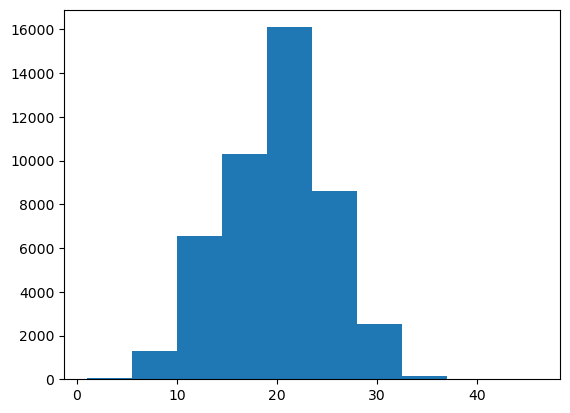

In [29]:
rv_l = [len(doc) for doc in pre_train_dataset['input_ids']]
print('Mean of the document length: {}'.format(np.mean(rv_l)))
print('Median of the document length: {}'.format(np.median(rv_l)))
print('Maximum document length: {}'.format(np.max(rv_l)))

plt.hist(rv_l)

We now neeed to choose a fixed sequence length, then *pad* the documents that are shorter than this maximum by adding a special token to the start of the sequence. The special pad token has an input value of 0. Any documents that exceed the length will be truncated.

**TO-DO 11:** Complete the padding code below to insert 0s at the start of any sequences that are too short, and to truncate any sequences that are too long.

In [30]:
sequence_length = 30  # truncate all docs longer than this. Pad all docs shorter than this.

def pad_text(sample):
    ###WRITE YOUR OWN CODE HERE
    ids = sample["input_ids"]
    if len(ids) < sequence_length:
        sample["input_ids"] = [0] * (sequence_length - len(ids)) + ids  # left-pad
    else:
        sample["input_ids"] = ids[:sequence_length]  # truncate



    ##########
    return sample

# The map method will call pad_text for every document in the dataset
pad_train_dataset = pre_train_dataset.map(pad_text)

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

We now have our data in almost the right format! To train a model using PyTorch, we are going to wrap our dataset in a [DataLoader object](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader). This allows the training process to select random subsets of the dataset -- mini-batches -- which it will use for learning with mini-batch stochastic gradient descent.

In [31]:
from torch.utils.data import DataLoader, TensorDataset

batch_size = 64

# convert from the Huggingface format to a TensorDataset so we can use the mini-batch sampling functionality
def convert_to_data_loader(dataset, num_classes):
    # convert from list to tensor
    input_tensor = torch.from_numpy(np.array(dataset['input_ids']))
    label_tensor = torch.from_numpy(np.array(dataset['label'])).long()
    tensor_dataset = TensorDataset(input_tensor, label_tensor)
    loader = DataLoader(tensor_dataset, batch_size=batch_size, shuffle=True)

    return loader

num_classes = len(np.unique(pad_train_dataset["label"]))   # number of possible labels 

train_loader = convert_to_data_loader(pad_train_dataset, num_classes)

In [32]:
num_classes

3

Let's preprocess the development and test set as well. We need the dev set when training our network to the model's fit, and to assess its performance with different hyperparameter settings. We use the test set to evaluate the final model on data that was not seen during its development to provide a fairer assessment of the model's generalisation. 

In [33]:
pre_dev_dataset = dev_dataset.map(tok_text).map(encode_text)
pad_dev_dataset = pre_dev_dataset.map(pad_text)
dev_loader = convert_to_data_loader(pad_dev_dataset, num_classes)

pre_test_dataset = test_dataset.map(tok_text).map(encode_text)
pad_test_dataset = pre_test_dataset.map(pad_text)
test_loader = convert_to_data_loader(pad_test_dataset, num_classes)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

As shown in the diagram above, we will build a NN with three different layers for sentiment classification.

### Embedding layer
In the embedding layer, the network will embed each term in the vocabulary with an embedding of a given size (dimension).
The module `nn.Embedding()` creates a simple lookup table that stores embeddings of a fixed dictionary and size.
This module is often used to store word embeddings and retrieve them using indices.
The module's input is a list of indices, and the output is the corresponding word embeddings.

[Documentation for Embedding Class](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html)

### Fully-connected layer
Fully-connected layers in a neural network are those layers where all the inputs from the previous layer are connected to every unit of the fully-connected layer. Here we will use fully-connected layers for the hidden layer and output layer. In Pytorch this kind of layer is implemented by combining the 'Linear' class with a nonlinear activation function:

https://pytorch.org/docs/stable/generated/torch.nn.Linear.html

## Activation functions
In Pytorch, the activation function is not included in the Linear class (or other kinds of neural network layer), so we need to explicitly connect each layer to an activation function.
In Pytorch, we construct a neural network by connecting up the output of each component to the input of the next, thereby creating a computation graph.
To complete the hidden layer, we connect the ouput of the linear layer to a ReLU activation function, thereby creating a nonlinear function.

The cell below defines a class for our neural text classifier. The constructor creates each of the layers and the activations. The dimensions of each layer need to be correct so that the output of one layer can be passed as input to the next, but the code is not yet complete.

Below the constructor is the forward method. This is called in the 'forward pass' to map the neural network's inputs to its outputs. In PyTorch, we pass data through each layer of the model, connecting them together, then returning the output of the final layer.

**TO-DO 12:** Complete the constructor and the forward method below for a NN with three layers. The places where you need to add code are marked in the cell below. Refer to the Pytorch documentation for additional help.

In [39]:
from torch import nn

class FFTextClassifier(nn.Module):
    
    def __init__(self, vocab_size, sequence_length, embedding_size, hidden_size, num_classes):
        super(FFTextClassifier, self).__init__()

        self.embedding_size = embedding_size

        # Here we just need to construct the components of our network. We don't need to connect them together yet.
        self.embedding_layer = nn.Embedding(vocab_size, embedding_size) # embedding layer
        
        ### COMPLETE THE CODE HERE: WRITE IN THE MISSING ARGUMENTS SPECIFYING THE DIMENSIONS OF EACH LAYER
        self.hidden_layer = nn.Linear(sequence_length * embedding_size, hidden_size) # Fully connected hidden layer
        self.activation = nn.ReLU() # Hidden layer
        ##########
        
        self.output_layer = nn.Linear(hidden_size, num_classes) # Fully connected output layer

        
        
    def forward (self, input_words):
        # Input dimensions are:  (batch_size, seq_length)
        embedded_words = self.embedding_layer(input_words)  # (batch_size, seq_length, embedding_size)

        # flatten the sequence of embedding vectors for each document into a single vector.
        embedded_words = embedded_words.reshape(embedded_words.shape[0], sequence_length*self.embedding_size)  # batch_size, seq_length*embedding_size

        z = self.hidden_layer(embedded_words)   # (batch_size, hidden_size)
        
        ### ADD THE MISSING LINE HERE
        h = self.activation(z)
        ########

        output = self.output_layer(h)                      # (batch_size, num_classes)

        # Notice we haven't applied a softmax activation to the output layer -- it's not required by Pytorch's loss function.

        return output

Now the class is complete. 

**TO-DO 13:** In the next cell, create a NN with the FFTextClassifier class we wrote.

Hint: `model = FFTextClassifier(...)`

In [40]:
vocab_size = len(dictionary) + 1  # add one for the padding tokens
embedding_size = 25  # number of dimensions for embeddings
hidden_size = 16 # number of hidden units

###WRITE YOUR OWN CODE HERE
model = FFTextClassifier(vocab_size, sequence_length, embedding_size, hidden_size, num_classes)


After desigining our network, we need to create a training function to calculate the loss for each input and perform backpropagation to optimise the network.
During training, the weights of all the layers will be updated.

Below, we build a training function to train the NN over a fixed number of epochs (an epoch is one iteration over the whole training dataset).
The function also prints the performance of both training and development/validation set after each epoch.

Here we use cross-entropy loss, which is the standard loss function for classification that we also used for logistic regression. The module `nn.CrossEntropyLoss()` operates directly on the output of our output layer, so we don't have to implement the softmax layer within the forward() method.

Cross Entropy Loss: https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html

The optimizer object implements a particular algorithm for updating the weights. Here, we will use the Adam optimizer, which is a variant of stochastic gradient descent method that tends to find a better solution in a smaller number of iterations than standard SGD.

Optimization: https://pytorch.org/docs/stable/optim.html

The cell below defines a training function for our classifier. 

**TO-DO 14:** First, try to follow what each line is doing. Then, modify the training function above to return the training and development (or 'validation') losses at each epoch.

In [41]:
from torch import optim

def train_nn(num_epochs, model, train_dataloader, dev_dataloader):
    
    learning_rate = 0.0005  # learning rate for the gradient descent optimizer, related to the step size

    loss_fn = nn.CrossEntropyLoss()  # create loss function object
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # create the optimizer
    
    all_train_losses = []
    all_dev_losses = []
    
    for e in range(num_epochs):
        # Track performance on the training set as we are learning...
        total_correct = 0
        total_trained = 0
        train_losses = []

        model.train()  # Put the model in training mode.

        for i, (batch_input_ids, batch_labels) in enumerate(train_dataloader):
            # Iterate over each batch of data
            # print(f'batch no. = {i}')

            optimizer.zero_grad()  # Reset the optimizer

            # Use the model to perform forward inference on the input data.
            # This will run the forward() function.
            output = model(batch_input_ids)

            # Compute the loss for the current batch of data
            batch_loss = loss_fn(output, batch_labels)

            # Perform back propagation to compute the gradients with respect to each weight
            batch_loss.backward()

            # Update the weights using the compute gradients
            optimizer.step()

            # Record the loss from this sample to keep track of progress.
            train_losses.append(batch_loss.item())

            # Count correct labels so we can compute accuracy on the training set
            predicted_labels = output.argmax(1)
            total_correct += (predicted_labels == batch_labels).sum().item()
            total_trained += batch_labels.size(0)

        train_accuracy = total_correct/total_trained*100

        print("Epoch: {}/{}".format((e+1), num_epochs),
              "Training Loss: {:.4f}".format(np.mean(train_losses)),
              "Training Accuracy: {:.4f}%".format(train_accuracy))
        
        all_train_losses.append(np.mean(train_losses))
        
        model.eval()  # Switch model to evaluation mode - turn off any random steps such as dropout
        total_correct = 0
        total_trained = 0
        dev_losses = []

        for dev_input_ids, dev_labels in dev_dataloader:
            dev_output = model(dev_input_ids)
            ### ANSWER CODE HERE
            dev_loss = loss_fn(dev_output, dev_labels)
            #######

            # Save the loss on the dev set
            dev_losses.append(dev_loss.item())
            
            # Count the number of correct predictions
            predicted_labels = dev_output.argmax(1)
            total_correct += (predicted_labels == dev_labels).sum().item()
            total_trained += dev_labels.size(0)
            
        dev_accuracy = total_correct/total_trained*100
        
        ### ANSWER CODE HERE
        all_dev_losses.append(np.mean(dev_losses))
        ###
        
        print("Epoch: {}/{}".format((e+1), num_epochs),
              "Validation Loss: {:.4f}".format(np.mean(dev_losses)),
              "Validation Accuracy: {:.4f}%".format(dev_accuracy))

    return model, all_train_losses, all_dev_losses

**TO-DO 15:**  Train the network for 15 epochs and plot the losses by completing the cell below. At which epoch did we get the best model fit? How could we use the dev set losses to return the best model? Remember that neural networks tend to overfit if trained too long, as they have many parameters and are very flexible. 

Note that the answer can vary each time you run the training process due to random initialisation of the model weights and shuffling of the dataset. 

ANSWER
   * The plot shows the best fit around 5 epochs before it starts to overfit, as the validation loss converges while training loss goes down 
   * If dev set loss stops going down for a long time, but training set loss keeps decreasing, the model may be overfitting.
   * We can stop training at the point where dev set loss stops decreasing 
   * Or we could save the model with best dev set performance and use that model to make predictions.

Epoch: 1/10 Training Loss: 1.0117 Training Accuracy: 45.3886%
Epoch: 1/10 Validation Loss: 1.0153 Validation Accuracy: 44.4500%
Epoch: 2/10 Training Loss: 0.9771 Training Accuracy: 50.0800%
Epoch: 2/10 Validation Loss: 0.9983 Validation Accuracy: 46.0000%
Epoch: 3/10 Training Loss: 0.9331 Training Accuracy: 54.3023%
Epoch: 3/10 Validation Loss: 0.9862 Validation Accuracy: 48.4000%
Epoch: 4/10 Training Loss: 0.8808 Training Accuracy: 57.9612%
Epoch: 4/10 Validation Loss: 0.9872 Validation Accuracy: 50.6000%
Epoch: 5/10 Training Loss: 0.8284 Training Accuracy: 61.4557%
Epoch: 5/10 Validation Loss: 0.9856 Validation Accuracy: 50.0500%
Epoch: 6/10 Training Loss: 0.7779 Training Accuracy: 64.4985%
Epoch: 6/10 Validation Loss: 0.9754 Validation Accuracy: 51.5500%
Epoch: 7/10 Training Loss: 0.7298 Training Accuracy: 67.0810%
Epoch: 7/10 Validation Loss: 0.9852 Validation Accuracy: 52.8000%
Epoch: 8/10 Training Loss: 0.6845 Training Accuracy: 69.7599%
Epoch: 8/10 Validation Loss: 1.0171 Valida

Text(0, 0.5, 'loss')

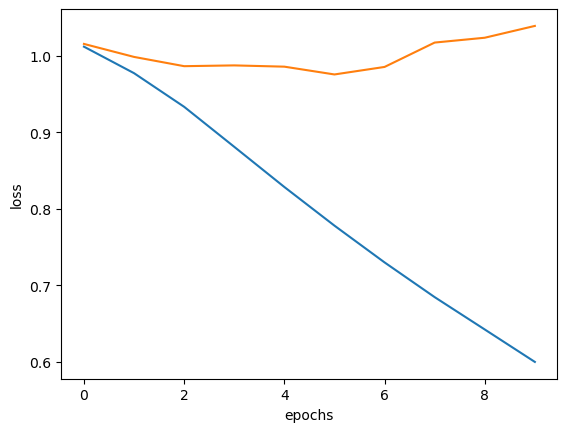

In [43]:
import matplotlib.pyplot as plt

num_epochs = 10

plt.figure()

###WRITE YOUR OWN CODE HERE
trained_model, all_train_losses, all_dev_losses = train_nn(num_epochs, model, train_loader, dev_loader)
plt.plot(range(num_epochs), all_train_losses, label='train loss')
plt.plot(range(num_epochs), all_dev_losses, label='dev loss')

####

plt.xlabel('epochs')
plt.ylabel('loss')

The code below obtains predictions from our neural network:

In [44]:
def predict_nn(trained_model, test_loader):

    trained_model.eval()  # switch off some randomisation used during training (dropout) to give consistent predictions

    gold_labs = []  # gold labels to return
    pred_labs = []  # predicted labels to return
    
    for inputs, labels in test_loader:
        test_output = trained_model(inputs)  # run the forward() function on the inputs
        predicted_labels = test_output.argmax(1)  # select the class labels with highest logits as our predictions

        gold_labs.extend(labels.tolist())
        pred_labs.extend(predicted_labels.tolist())
    
    return gold_labs, pred_labs

gold_labs, pred_labs = predict_nn(trained_model, test_loader)

Now, we can use pretrained word embeddings instead of learning them from scratch during training.
Here, we will use pretrained GloVe embeddings that were trained on Tweets, as the text domain is the same as our hate speech dataset. The embedding matrix is used to initialise the embedding layer. The code below converts the GloVe embeddings into an embedding matrix suitable for PyTorch:

In [45]:
import gensim.downloader

# download the word embeddings from Gensim
glove_wv = gensim.downloader.load('glove-twitter-25')

In [46]:
embedding_matrix = torch.zeros((vocab_size, glove_wv.vector_size))

glove_wv.vectors

count = 0

for word in glove_wv.index_to_key:
    if word in dictionary.token2id:
        word_idx = dictionary.token2id[word]
    
        embedding_matrix[word_idx, :] = torch.from_numpy(glove_wv[word])
        count +=1 
        
print(embedding_matrix)
print(count)

C:\Users\rohta\AppData\Local\Temp\ipykernel_11788\3602796992.py:11: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_numpy.cpp:212.)
  embedding_matrix[word_idx, :] = torch.from_numpy(glove_wv[word])


tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-1.2062,  1.5804,  0.9181,  ...,  1.6417, -0.6852, -0.3649],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]])
21935


The class below extends the FFTextClassifier class to make use of the pretrained embeddings. This means that it inherits all of its functionality, but we overwrite the constructor (the `__init__` method). This way, we don't need to define the forward function again, as it will be the same as before.

The embedding layer is now different as it loads pretrained embeddings from our matrix. The argument `freeze` determines whether the embeddings remain fixed to their pretrained values (if `freeze=True`) or are updated through backpropagation to fit them to the dataset.

**TO-DO 16:** Complete the arguments in the cell below for the `FFTextClassifierWithEmbeddings` constructor. You need to set the dimensions of the neural network layers.  

Note that freezing the pretrained embeddings will speed up the training process, but may make the model less accurate.

In [47]:
class FFTextClassifierWithEmbeddings(FFTextClassifier):

    def __init__(self, hidden_size, sequence_length, num_classes, embedding_matrix):
        super(FFTextClassifier, self).__init__()

        self.embedding_size = embedding_matrix.shape[1] 

        # Here we just need to construct the components of our network. We don't need to connect them together yet.
        self.embedding_layer = nn.Embedding.from_pretrained(embedding_matrix, freeze=False) # embedding layer

        ### COMPLETE THE ARGUMENTS TO SPECIFY THE DIMENSIONS OF THE LAYERS
        self.hidden_layer = nn.Linear(sequence_length * self.embedding_size, hidden_size) # Hidden layer
        self.activation = nn.ReLU() # Hidden layer
        ###
        
        self.output_layer = nn.Linear(hidden_size, num_classes) # Full connection layer

**TO-DO 17:** Call the constructor for FFTextClassifierWithEmbeddings, then train the model, then obtain test set predictions (as in the experiment above)

In [48]:
### COMPLETE THE CODE BELOW
ff_emb_model = FFTextClassifierWithEmbeddings(
    hidden_size=hidden_size,
    sequence_length=sequence_length,
    num_classes=num_classes,
    embedding_matrix=embedding_matrix
)
###

trained_emb_model, _, _ = train_nn(5, ff_emb_model, train_loader, dev_loader)
gold_labs_emb, pred_labs_emb = predict_nn(trained_emb_model, test_loader)

Epoch: 1/5 Training Loss: 1.0016 Training Accuracy: 47.8965%
Epoch: 1/5 Validation Loss: 0.9829 Validation Accuracy: 50.8000%
Epoch: 2/5 Training Loss: 0.9274 Training Accuracy: 54.1116%
Epoch: 2/5 Validation Loss: 0.9373 Validation Accuracy: 54.1500%
Epoch: 3/5 Training Loss: 0.8410 Training Accuracy: 59.9693%
Epoch: 3/5 Validation Loss: 0.8916 Validation Accuracy: 56.8500%
Epoch: 4/5 Training Loss: 0.7555 Training Accuracy: 65.4280%
Epoch: 4/5 Validation Loss: 0.8715 Validation Accuracy: 59.9000%
Epoch: 5/5 Training Loss: 0.6794 Training Accuracy: 69.8871%
Epoch: 5/5 Validation Loss: 0.8605 Validation Accuracy: 60.6000%


The code below computes F1 scores so we can compare the two neural networks and the previous linear classifiers. 

Can you explain why the neural networks are not particularly strong compared to the linear models? 

In [49]:
from sklearn.metrics import f1_score

# Evaluate the models using F1 score
print(f'Random embedding intialisation: {f1_score(gold_labs, pred_labs, average="macro")}')
print(f'Frozen pretrained GloVe embeddings: {f1_score(gold_labs_emb, pred_labs_emb, average="macro")}')

# note that gold_labs_emb and gold_labs are different -- the dataset gets shuffled each time we iterate using the data loader. 

Random embedding intialisation: 0.44923599957599264
Frozen pretrained GloVe embeddings: 0.5068099608767288


# OPTIONAL: Improving the Classifiers

## Lexicon Features

There are various ways that we could improve the classifiers above. One way to improve the feature vectors used for naïve Bayes or logistic regression is to add more task-specific features. The NLTK library contains sentiment lexicons, which are lists of words with negative or positive connotations, which we can use to add more features.



In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

analyser = SentimentIntensityAnalyzer()

Let's have a look at the sentiment scores for some words in the lexicon by running the code below. What do the scores mean and why do some words have no score?

In [ ]:
testwords = ['happy', 'wonderful', 'horrible', 'boring', 'tablecloth', 'not']

for word in testwords:
    if word in analyser.lexicon:
        print(f'{word}: {analyser.lexicon[word]}')
    else:
        print(f'{word}: NOT IN LEXICON')

Now we would like to use this function to compute counts of all positive and negative words in a document. Let's start by recording whether the words in our vocabulary are positive or negative:

In [ ]:
# Print out some of the features in the vocabulary:
print(list(vectorizer.vocabulary_)[:20])

vocabulary = vectorizer.vocabulary_

lex_pos_scores = np.zeros((1, len(vocabulary)))
lex_neg_scores = np.zeros((1, len(vocabulary)))

# get the Vader lexicon scores for each word in our vocabulary
for i, term in enumerate(vocabulary):
    if term in analyser.lexicon and analyser.lexicon[term] > 0:
        lex_pos_scores[0, i] = 1
    elif term in analyser.lexicon and analyser.lexicon[term] < 0:
        lex_neg_scores[0, i] = 1

Now let's compute the counts of positive and negative words in the dataset:

In [ ]:
# Compute the scores for each instance in the data set. 

# Multiply the lexicon scores by the feature vectors, then sum over the 
# vocabulary to get the total positive and total negative counts:
lex_pos_train = np.sum(X_train.multiply(lex_pos_scores), axis=1)
lex_pos_test = np.sum(X_test.multiply(lex_pos_scores), axis=1)

lex_neg_train = np.sum(X_train.multiply(lex_neg_scores), axis=1)
lex_neg_test = np.sum(X_test.multiply(lex_neg_scores), axis=1)

Finally, we can append the counts to the feature vector and treat them as extra features:

In [ ]:
from scipy.sparse import hstack

X_train = hstack((X_train, lex_pos_train, lex_neg_train))
X_test = hstack((X_test, lex_pos_test, lex_neg_test))

**TO-DO 18:** Use the new X_train and X_test feature vectors to train and evaluate your classifier. 
Does adding the lexicon features improve performance?

In [ ]:
### WRITE YOUR OWN CODE HERE


## Recurrent Neural Networks

The neural network we have tried so far uses fully-connected layers, which means that the weights applied to a particular word's embedding are specific to the location of the word in the sentence -- shifting the tokens along by one could produce a completely different result. We could improve this by using a recurrent neural network layer, that processes the tokens sequentially. The code below adapts our class to use a bidirectional LSTM for the hidden layer(s). 

We do not cover LSTMs in depth in this unit: they have largely been superseded by a newer type of model, the transformer. However, this is an interesting way to learn about changing the type of layer in a neural network to something that better suits the data.

**TO-DO 19:** Complete the constructor and forward method below and test the class with the LSTM layer.

In [ ]:
class LSTMTextClassifierWithEmbeddings(FFTextClassifier):

    def __init__(self, hidden_size, sequence_length, num_classes, embedding_matrix):
        super(FFTextClassifier, self).__init__()

        self.embedding_size = embedding_matrix.shape[1] 

        # Here we just need to construct the components of our network. We don't need to connect them together yet.
        self.embedding_layer = nn.Embedding.from_pretrained(embedding_matrix, freeze=False)

        self.hidden_layer = nn.LSTM(self.embedding_size, hidden_size, bidirectional=True, batch_first=True)
        
        ### COMPLETE THE ARGUMENTS TO SPECIFY THE DIMENSIONS OF THE LAYERS
        self.activation = nn.ReLU() # Hidden layer
        self.output_layer = nn.Linear() # Full connection layer

    def forward (self, input_words):
        # Input dimensions are:  (batch_size, seq_length)
        embedded_words = self.embedding_layer(input_words)  # (batch_size, seq_length, embedding_size)

        # flatten the sequence of embedding vectors for each document into a single vector.
        # embedded_words = embedded_words.reshape(embedded_words.shape[0], sequence_length*self.embedding_size)  # batch_size, seq_length*embedding_size
        _, (z, _) = self.hidden_layer(embedded_words)   # (2, batch_size, hidden_size)
        z = z.swapaxes(0, 1).flatten(1)
        
        ### ADD THE MISSING LINE HERE

        ########
        
        output = self.output_layer(h)                      # (batch_size, num_classes)

        # Notice we haven't applied a softmax activation to the output layer -- it's not required by Pytorch's loss function.

        return output

# WRITE YOUR CODE HERE TO TEST THE LSTM CLASSIFIER
gold_labs, pred_labs_lstm = ...

In [ ]:
from sklearn.metrics import f1_score
print(f'LSTM + Pretrained GloVe embeddings: {f1_score(gold_labs, pred_labs_lstm, average="macro")}')